# 1D Finite element method

While Rylander's textbook starts in chapter 6.2 with discussion the application of FEM to solve a 1D problem, it never presents a code or any implementation detail. For the sake of completeness, and hopefully, also for the sake of clarity, we consider here the simplest possible FEM case.

In subsequent sections of the notebook, we also discuss the computation of eigenvalues, which is content of Chapter 6.5, and the application of numerical integration techniques to compute the inner products of basis and test functions (see chapter 6.6). The use of higher-order basis functions is added as extra material, which we might or might not cover in class. You are invited to study the sections by yourself, but you can also wait until we reach those in class.

The code will use some more advance Julia techniques so check the Julia documentation carefully and acquaint yourself with these techniques. 

In [1]:
using StaticArrays

"""
    Mesh{I <: Integer, F <: Real}

Stores a 1D mesh, where the vector vertices contains the position of the vertices 
on the x-axis and the vector segments the segments described by the beginning and 
the ending vertex (where the first vertex in the SVector{2, I} denotes the
beginning vertex).
"""
struct Mesh{I <: Integer, F <: Real}
    vertices::Vector{F}  #vector (reserved word creo, con elementos tipo F)
    segments::Vector{SVector{2, I}}  #static vector size 2, consisting of I elements
end

"""
    generate_uniform_mesh(start_point, end_point, n)

Generates a uniformly spaced mesh of a Cartesian axis.
"""
function generate_uniform_mesh(start_point, end_point, n)
    
    start_point > end_point && error("Start point comes after end point")
    
    #The |> operator is used to pass the Range object to the collect function, 
    #which converts the Range object to an array
    v = range(start=start_point, stop=end_point, length=n) |> collect

    ST = SVector{2, Int}
    
    s = [ST(i, i+1) for i=1:(length(v)-1)]
    println(s)
    return Mesh(v, s)
end

function numvertices(Ω)
    return length(Ω.vertices)
end

function vertices(Ω)
    return Ω.vertices
end

function segments(Ω)
   return Ω.segments
end

function numsegments(Ω)
    return length(Ω.segments)
end

function integertype(Γ)
    return typeof(Γ).parameters[1]
end

"""
    verticestosegments(Ω)

Returns a vector, which provides the segments attached to each node
(note that there are not more than two).
To denote whether a vertex is the end vertex of a segment, it is stored
with a minus sign.
"""

#enumerate the regresa dos valores digamos: (index,value) 
#index siempre empieza en 1, entonces aguas si tú quieres otro número, value pues ya es el objeto en si en tu array ohm
function verticestosegments(Ω)
    v2c = [integertype(Ω)[] for i = 1:numvertices(Ω)]
    for (i, segment) in enumerate(segments(Ω))
        push!(v2c[segment[1]], i)
        push!(v2c[segment[2]], -i)
    end
    return v2c
end


verticestosegments (generic function with 1 method)

In the following, we build the system matrix using analytic expression for the local stiffness matrix
\begin{equation}
[\mathbf S^e]_{ij} = \int_{x_1^e}^{x_2^e} \frac{\mathrm{d}}{\mathrm{d}x}\varphi^e_i(x) \frac{\mathrm{d}}{\mathrm{d}x}\varphi^e_j(x) \mathrm{d}x
\end{equation}
and the local mass matrix
\begin{equation}
[\mathbf M^e]_{ij} = \int_{x_1^e}^{x_2^e} \varphi^e_i(x) \varphi^e_j(x) \mathrm{d}x
\end{equation}
using analytic expressions (see HA 5.1, where it is your job to compute those expressions), where $\varphi^e_i(x)$ are pyramid functions. Mathematically, they belong to the family of Lagrange interpolative functions $P_i(p, ξ)$ of linear order, that is, $p=1$. On the unit interval, we have $P_0(1, ξ) = 1 - ξ$ and $P_1(1, ξ)=ξ$.



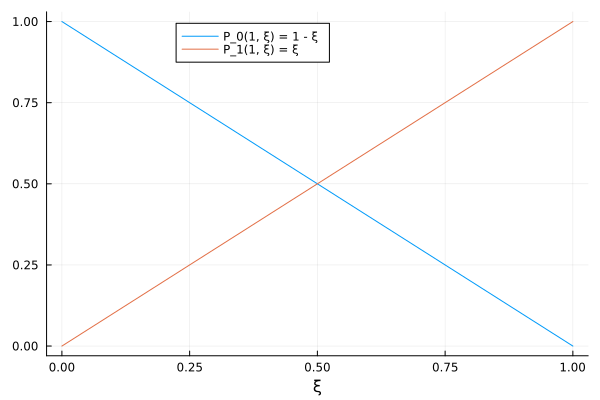

In [2]:
using Plots
ξ = 0:0.01:1 |> collect
plot(ξ, 1 .- ξ, label="P_0(1, ξ) = 1 - ξ")
plot!(ξ, ξ, label="P_1(1, ξ) = ξ", legend=:top, xlabel="ξ")

Solving the electric potential in a 1D domain with Dirichlet BC in free-space is actually quite boring: the solution is simply an analytic function connecting the two Dirichlet potential values. To make it a bit more interesting, I allow to define a dielectric window. Can you detect where the window is located and how large it is?

Admittedly, the code is a bit artificial as the dielectric window is hard-coded in the assembly routine and decoupled from the mesh...

SVector{2, Int64}[[1, 2], [2, 3], [3, 4], [4, 5], [5, 6], [6, 7], [7, 8], [8, 9], [9, 10], [10, 11], [11, 12], [12, 13], [13, 14], [14, 15], [15, 16], [16, 17], [17, 18], [18, 19], [19, 20], [20, 21], [21, 22], [22, 23], [23, 24], [24, 25], [25, 26], [26, 27], [27, 28], [28, 29], [29, 30], [30, 31], [31, 32], [32, 33], [33, 34], [34, 35], [35, 36], [36, 37], [37, 38], [38, 39], [39, 40], [40, 41], [41, 42], [42, 43], [43, 44], [44, 45], [45, 46], [46, 47], [47, 48], [48, 49], [49, 50], [50, 51], [51, 52], [52, 53], [53, 54], [54, 55], [55, 56], [56, 57], [57, 58], [58, 59], [59, 60], [60, 61], [61, 62], [62, 63], [63, 64], [64, 65], [65, 66], [66, 67], [67, 68], [68, 69], [69, 70], [70, 71], [71, 72], [72, 73], [73, 74], [74, 75], [75, 76], [76, 77], [77, 78], [78, 79], [79, 80], [80, 81], [81, 82], [82, 83], [83, 84], [84, 85], [85, 86], [86, 87], [87, 88], [88, 89], [89, 90], [90, 91], [91, 92], [92, 93], [93, 94], [94, 95], [95, 96], [96, 97], [97, 98], [98, 99], [99, 100]]
Solve sy

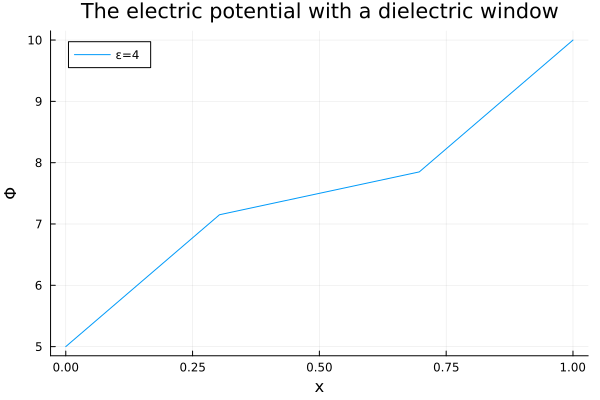

In [3]:
using LinearAlgebra
using Plots

function localstiffnessmatrix_analyticintegration!(x, Se; a=x->1.0)
    Se[1, 1] = 1/(x[2] - x[1])
    Se[2, 2] = 1/(x[2] - x[1])
    Se[1, 2] = 1/(x[1] - x[2])
    Se[2, 1] = 1/(x[1] - x[2])
    # Note: we cannot use Se =  Se .* a((x[1] + x[2])/2.0)
    # This would create a local copy of Se in the function
    # We need to use 
    Se[:, :] = Se .* a((x[1] + x[2])/2.0) # Approximate as constant per segment
end

function localmassmatrix_analyticintegration!(x, Me; b=x->1.0)
    Me[1, 1] = 1/3*(x[2] - x[1])
    Me[2, 2] = 1/3*(x[2] - x[1])
    Me[1, 2] = 1/6*(x[2] - x[1])
    Me[2, 1] = 1/6*(x[2] - x[1])
    Me[:, :] = Me .* b((x[1] + x[2])/2.0)
end

function dielectricwindow(x; ε=1.0, window_radius=0.2, window_center = 0.5)
    return (abs(x - window_center) < window_radius ? ε : 1.0)
end

function assemble(Ω::Mesh{I,F}; a=x->1.0, b=x->1.0) where {I,F}
    S = zeros(F, numvertices(Ω), numvertices(Ω))
    Se = zeros(F, 2, 2)

    M = zeros(F, numvertices(Ω), numvertices(Ω))
    Me = zeros(F, 2, 2)
    
    for segment in segments(Ω)
        x = [vertices(Ω)[vertex] for vertex in segment] 

        # Compute the element matrix and add
        # the contribution to the global matrix.
        localstiffnessmatrix_analyticintegration!(x, Se, a=a)
        S[segment, segment] += Se
        
        localmassmatrix_analyticintegration!(x, Me, b=b)
        M[segment, segment] += Me
    end
    
    return S, M
end

"""
    dirichletproblem(V_L, V_R, n; ε=x->1.0)

This functions obtains the weak solution of

∇⋅(ε(x)∇u) = 0 with u(0)=V_L and u(1)=V_R

by discretization the variational formulation

ε(x)∇v∇u = 0 for all v.

For the stiffness and mass matrix, the integrals
are computed analytically.
"""
function dirichletproblem(V_L, V_R, n; ε=x->1.0)
    # Create a mesh
    Ω = generate_uniform_mesh(0, 1, n)
    
    S, M = assemble(Ω, a=ε)
    
    # Left boundary node
    vleft = argmin(vertices(Ω))
    vright = argmax(vertices(Ω))
    vertices_ess = vcat(vleft, vright) # Boundary nodes for Dirichlet BC
    vertices_all = 1:numvertices(Ω)
    vertices_nat = setdiff(vertices_all, vertices_ess)
    S_nat = S[vertices_nat, vertices_nat]
    S_ess = S[vertices_nat, vertices_ess]
    Φ_ess = [V_L, V_R]
    
    # Solve the system of linear equations
    println("Solve system with number of unknowns: ", numvertices(Ω))    
    Φ_nat = S_nat\(-S_ess*Φ_ess)  

    # Build up the total solution.
    Φ = zeros(numvertices(Ω))
    Φ[vertices_ess] = Φ_ess
    Φ[vertices_nat] = Φ_nat
    
    return Φ, Ω
end

Φ, Ω = dirichletproblem(5, 10, 100, ε=x->dielectricwindow(x;ε=4.0))

plot(vertices(Ω), Φ, label="ε=4", xlabel="x", ylabel="Φ", title="The electric potential with a dielectric window", legend=:topleft)

# Eigenvalue computation
Computing eigenvalues by leveraging FEM is discussed in Chapter 6.5 of Rylander's textbook; however, the discussion is limited to the case of vector-valued eigenfunction as they appear for the curl-curl operator. In this section, we revisit the much simpler 1D, which we already discussed in chapter 3, where we used finite differences.

We are interested in computing the eigenvalues $k$ of the Laplace operator, that is, $Δu = -k^2 u$. We discretize the variational formulation $∇v⋅∇u = -k^2 vu$, which leads to the generalized eigenvalue problem $\mathbf{S}\mathbf{u} = λ \mathbf{M}\mathbf{u}$. This is different to the finite difference case, where no $\mathbf M$ matrix appeared. The so-called mass matrix is the discretization of identity operator, which was, in case of the finite-difference scheme, simply a unit matrix.


SVector{2, Int64}[[1, 2], [2, 3], [3, 4], [4, 5], [5, 6], [6, 7], [7, 8], [8, 9], [9, 10], [10, 11], [11, 12], [12, 13], [13, 14], [14, 15], [15, 16], [16, 17], [17, 18], [18, 19], [19, 20], [20, 21], [21, 22], [22, 23], [23, 24], [24, 25], [25, 26], [26, 27], [27, 28], [28, 29], [29, 30], [30, 31], [31, 32], [32, 33], [33, 34], [34, 35], [35, 36], [36, 37], [37, 38], [38, 39], [39, 40], [40, 41], [41, 42], [42, 43], [43, 44], [44, 45], [45, 46], [46, 47], [47, 48], [48, 49], [49, 50], [50, 51], [51, 52], [52, 53], [53, 54], [54, 55], [55, 56], [56, 57], [57, 58], [58, 59], [59, 60], [60, 61], [61, 62], [62, 63], [63, 64], [64, 65], [65, 66], [66, 67], [67, 68], [68, 69], [69, 70], [70, 71], [71, 72], [72, 73], [73, 74], [74, 75], [75, 76], [76, 77], [77, 78], [78, 79], [79, 80], [80, 81], [81, 82], [82, 83], [83, 84], [84, 85], [85, 86], [86, 87], [87, 88], [88, 89], [89, 90], [90, 91], [91, 92], [92, 93], [93, 94], [94, 95], [95, 96], [96, 97], [97, 98], [98, 99], [99, 100], [100, 10

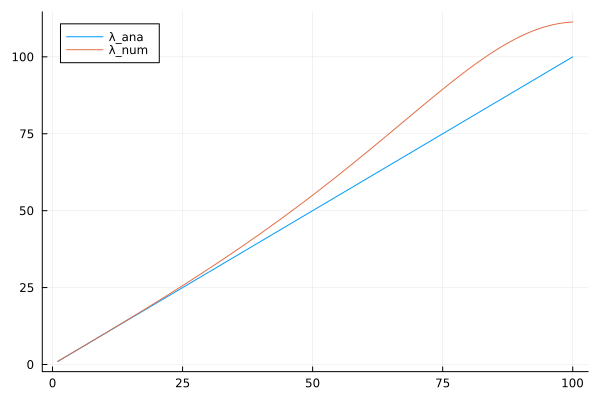

In [4]:
function compute_eigenvalues(n)
    # Create a mesh
    Ω = generate_uniform_mesh(0, π, n)
    
    S, M = assemble(Ω)
    
    # Left boundary node
    vleft = argmin(vertices(Ω))
    vright = argmax(vertices(Ω))
    vertices_ess = vcat(vleft, vright) # Boundary nodes for Dirichlet BC
    vertices_all = 1:numvertices(Ω)
    vertices_nat = setdiff(vertices_all, vertices_ess)
    S_nat = S[vertices_nat, vertices_nat]
    M_nat = M[vertices_nat, vertices_nat]
    λ, V = eigen(S_nat, M_nat)
    return λ, V, Ω
end

n = 100
λ, V, Ω = compute_eigenvalues(n + 2)

k = sqrt.(λ)

using Plots
plot(1:n, label="λ_ana")
plot!(k, label="λ_num", legend=:topleft)

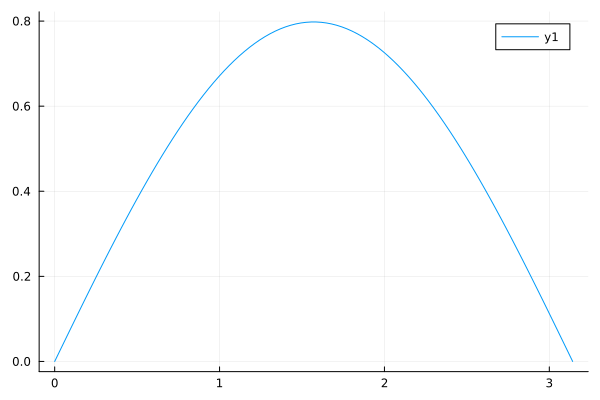

In [5]:
# Plot eigenvector
x = vertices(Ω)
v = vcat(0, V[:,1], 0) # Recall Dirichlet BC
plot(x, v )

In [6]:
# And here a bit of convergence analysis
function estimate_p(h, I)
    return log((I[end-2] - I[end-1])/(I[end-1] - I[end]))/log(h[end-2]/h[end-1])
end

n_vals = [100; 200; 400]
I = [compute_eigenvalues(n)[1][1] for n in n_vals]

# Estimate the order of convergence
@show p = estimate_p(n_vals, I)

SVector{2, Int64}[[1, 2], [2, 3], [3, 4], [4, 5], [5, 6], [6, 7], [7, 8], [8, 9], [9, 10], [10, 11], [11, 12], [12, 13], [13, 14], [14, 15], [15, 16], [16, 17], [17, 18], [18, 19], [19, 20], [20, 21], [21, 22], [22, 23], [23, 24], [24, 25], [25, 26], [26, 27], [27, 28], [28, 29], [29, 30], [30, 31], [31, 32], [32, 33], [33, 34], [34, 35], [35, 36], [36, 37], [37, 38], [38, 39], [39, 40], [40, 41], [41, 42], [42, 43], [43, 44], [44, 45], [45, 46], [46, 47], [47, 48], [48, 49], [49, 50], [50, 51], [51, 52], [52, 53], [53, 54], [54, 55], [55, 56], [56, 57], [57, 58], [58, 59], [59, 60], [60, 61], [61, 62], [62, 63], [63, 64], [64, 65], [65, 66], [66, 67], [67, 68], [68, 69], [69, 70], [70, 71], [71, 72], [72, 73], [73, 74], [74, 75], [75, 76], [76, 77], [77, 78], [78, 79], [79, 80], [80, 81], [81, 82], [82, 83], [83, 84], [84, 85], [85, 86], [86, 87], [87, 88], [88, 89], [89, 90], [90, 91], [91, 92], [92, 93], [93, 94], [94, 95], [95, 96], [96, 97], [97, 98], [98, 99], [99, 100]]
SVector{

-2.0169892897974946

# Numerical integral computation and higher-order basis functions

This sections shows a practical implementation of the numerical integration routines for the 1D case. Moreover, it show the use of higher-order basis functions, which we might not cover in class.

If we want to handle permittivity distributions $\varepsilon(x)$, which are not piecewise constant, using the analytic integral expression from above would mean that per cell we would approximate $\varepsilon(x)$ as piecewise constant. Since it is impractical to compute for each and every permittivity distribution analytic integral expressions, we can resort numerical quadrature rules to approximate
\begin{equation}
    \int_a^b f(x) \mathrm{d}x \approx \sum_{n=1}^N w_n f(x_n)\, ,
\end{equation}
where $w_n$ are the weights and $x_n$ the quadrature points. These depend on the quadrature rule choosen. In Chapter 2, we have encountered quadrature rules from the Newton-Cotes family and Gauss-Legendre quadrature rules. While the Newton-Cotes quadrature rules become unstable for large $N$, Gaussian quadratures are unconditionally stable, and what is more, for each $N$, polynomials of order up to $2N-1$ can be exactly integrated. In 1814, Gauss published this rule. It is called Gauss-Legendre due to Jacobi, who pointed out that the $x_n$ are the zeros of the $N$ degree Legendre polynomial $P_N(x)$ and $w_n =  2(1-x_n^2)^{-1}[P_N'(x_n)]^{-2}$.

While numerical quadrature is less accurate than analytic expression, it is more flexible, not only regarding inhomogeneous media or charge distributions, but also regarding higher-order basis functions.

We are going to use the package FastGaussQuadrature. It provides $x_n$ and $w_n$ for the integral $\int_{-1}^{1}$. Thus we employ the substitution of variables $y = \frac{-2a}{a-b}x + 1$ and $\mathrm{d}y = \frac{-2a}{a-b}\mathrm{d}x \Rightarrow \frac{b-a}{2a} \mathrm{d} y = \mathrm{d}x $ such that we obtain the nodes and weights for $\int_a^b \mathrm{d}x$.

In [7]:
using FastGaussQuadrature
using Test

import FastGaussQuadrature.gausslegendre

function gausslegendre(n, a, b)
    x, w = gausslegendre(n)
    w = w .* (b-a)/2.0
    x = x .* (b-a)/(2.0) .+ (b+a)/2 
    return x, w
end

x, w = gausslegendre(2, 0, 3)

f(x) = x^2

@test w'*f.(x) ≈ 9

┌ Info: Precompiling FastGaussQuadrature [442a2c76-b920-505d-bb47-c5924d526838]
└ @ Base loading.jl:1662


Test Passed

The pyramid basis functions (aka tent functions, aka piecewise linear functions etc.) are defined on the vertices of mesh (see lecture). If we look at a single segment, these functions can be considered as linear Lagrange interpolative functions (see the first part of this notebook, with the plots for $P_0(1, ξ)$ and $P_1(1, ξ)$). A general definition of linear Lagrange functions is
\begin{equation}
    P_i(p, ξ) = \prod_{j=0\\ j\neq i}^p \frac{p ξ - j}{i - j}\, .
\end{equation}
The following code implements those functions as well as their first-order derivatives, and it shows plots for $p=2$ (quadratic order).

In [8]:
function P(i, p, ξ)
    val = 1.0
    for j=0:p
        if j != i
            val *= (p*ξ-j)/(i-j)
        end
    end
    return val 
end

# Let's right some unit tests
P02(x) = (1-2x)*(1-x)
@test P(0,2,0.2) ≈ P02(0.2)

P03(x) = (1-3*x)*(2-3*x)*(1-x)/2
P13(x) = 9*x*(2-3*x)*(1-x)/2
P23(x) = -9*x*(1-3*x)*(1-x)/2
P33(x) = x*(1-3*x)*(2-3*x)/2

@test P(0, 3, 0.2) ≈ P03(0.2) 
@test P(1, 3, 0.2) ≈ P13(0.2) 
@test P(2, 3, 0.2) ≈ P23(0.2)
@test P(3, 3, 0.2) ≈ P33(0.2)

function dP(i, p, ξ)
    sumval = 0.0
    for k=0:p
        multval = 1.0
        if k != i
            for j=0:p
                if i != j
                    if k == j
                        multval *= p/(i-j)
                    else
                        multval *= (p*ξ-j)/(i-j)
                    end
                end
            end
            sumval += multval
        end
    end
    return sumval
end

# Right your own unit tests here...

dP (generic function with 1 method)

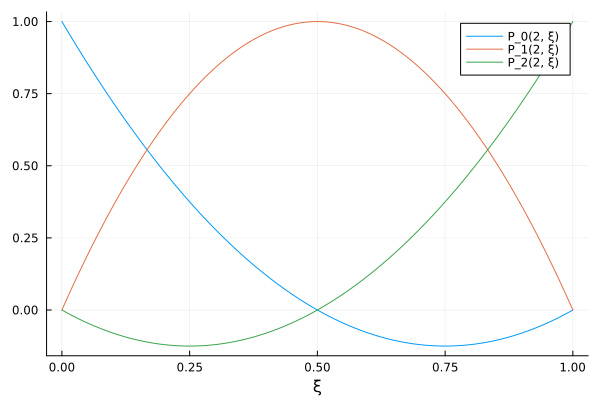

In [9]:
ξ = 0:0.01:1 |> collect

plot(ξ, P.(0, 2, ξ), label="P_0(2, ξ)")
plot!(ξ, P.(1, 2, ξ), label="P_1(2, ξ)")
plot!(ξ, P.(2, 2, ξ), label="P_2(2, ξ)", xlabel="ξ")

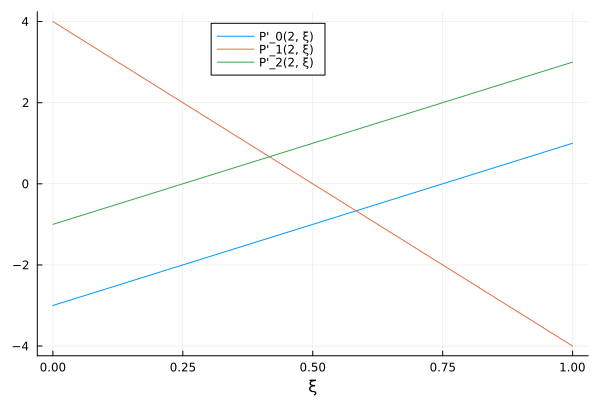

In [10]:
ξ = 0:0.01:1 |> collect

plot(ξ, dP.(0, 2, ξ), label="P'_0(2, ξ)")
plot!(ξ, dP.(1, 2, ξ), label="P'_1(2, ξ)")
plot!(ξ, dP.(2, 2, ξ), label="P'_2(2, ξ)", xlabel="ξ", legend=:top)

In the above code, we followed the spirit of the textbook, where it is simply assumed that the basis functions are associated with the vertices of the mesh. This becomes impractical, for more complex scenarios, in particular, when higher-order basis functions are used. We need to define an abstraction layer for basis functions, which we do by introducing an abstract type `FunctionSpace` and the `Lagrange` type as concrete implementation of a type.

In [11]:
abstract type FunctionSpace end

"""
    LocalShape{I, F}

LocalShapes connects a global segment id, with the local
reference id, on which the basis function is defined.
For linear order, p=1, refid is 1 or 2, for p=2, refid can be 1, 2, or 3.
Coeff denotes the value that the function assumes at the node at
the ref id.
"""
struct LocalShape{I, F}
  segmentid::I
  refid::I
  coeff::F
end

"""
    Lagrange{M, I, F, P} <: FunctionSpace

Basis functions will in general straddle two segments
(for 2D or 3D codes, it would be even several triangles or tetrahedrons).
The information, where a function lives  on a segment is stored
in `LocalShapes`. `fns` is a vector of all functions and has as entries
for each function a vector of `LocalShapes` that describe the function.

`pos` is a vector that describes the position on the line of real numbers
where the basis function is located (that is, where it asssumes unit value).

# Template arguments
M: Type of the mesh
I: Type of integer
F: Type of scalars (Float)
P: Order of Lagrange functions
"""
struct Lagrange{M, I, F, P} <: FunctionSpace
    mesh::M
    fns::Vector{Vector{LocalShape{I, F}}}
    pos::Vector{F}
end

function Lagrange(Ω::Mesh{I, F}, p) where {I, F}
    numlagrangefunctions = 0
    fns = Vector{LocalShape{I, F}}[]
    pos = F[]
    
    vs = vertices(Ω)
    v2c = verticestosegments(Ω)
    
    for (vertex, cells) in enumerate(v2c)
        localshapes = LocalShape{I, F}[]
        for cell in cells
            push!(localshapes, LocalShape(abs(cell), sign(cell) == 1.0 ? 1 : (p+1), 1.0))
        end
        push!(fns, localshapes)
        push!(pos, vs[vertex])
    end
    
    # Define the functions, which are only in one segment
    # after the functions defined on the boundary vertices
    # of a segment.
    if p > 1
        for (segmentid,segment) in enumerate(segments(Ω))
            for i=1:(p-1)
                localshapes = LocalShape{I, F}[]
                position = vs[segment[1]]*(p-i)/p + vs[segment[2]]*(i/p)
                push!(localshapes, LocalShape(segmentid, i+1, 1.0))
                push!(fns, localshapes)
                push!(pos, position)
            end
        end
    end
        
    return Lagrange{Mesh{I, F}, I, F, p}(Ω, fns, pos)
end

numfunctions(space::FunctionSpace) = length(space.fns)
order(space::Lagrange{M, I, F, P}) where {M, I, F, P} = P
scalartype(space::Lagrange{M, I, F, P}) where {M, I, F, P} = F

Ω = generate_uniform_mesh(0, 1, 3)
@test numsegments(Ω) == 2
@test numvertices(Ω) == 3
X = Lagrange(Ω, 2)

@test numfunctions(X) == 5
@test X.pos[4] == 0.25
@test X.pos[5] == 0.75

function segmentstovertices(functionspace::Lagrange{M, I, F, P}) where {M, I, F, P}
    s2v = zeros(I, P+1, numsegments(functionspace.mesh))
    for (fnid, fn) in enumerate(functionspace.fns)
        for shape in fn
            s2v[shape.refid, shape.segmentid] = fnid
        end
    end
    s2v_final = SVector{P+1, I}[]
    for i=1:numsegments(functionspace.mesh)
        push!(s2v_final, SVector{P+1, I}(s2v[:,i]))
    end
    return s2v_final
end

s2v = segmentstovertices(X)

@test s2v[1][1] == 1
@test s2v[1][2] == 4 # the middle functions are numbered after the functions on the vertices of the mesh
@test s2v[1][3] == 2
@test s2v[2][1] == 2
@test s2v[2][2] == 5
@test s2v[2][3] == 3

Ω = generate_uniform_mesh(0, 1, 2)
X = Lagrange(Ω, 3)
s2v = segmentstovertices(X)
@test s2v[1] == [1, 3, 4, 2]

SVector{2, Int64}[[1, 2], [2, 3]]
SVector{2, Int64}[[1, 2]]


Test Passed

Now we are in the position to present the assembly routines. We use the analytic code, as well as analytic formulas for quadratic and cubic elements as a means to verify our code. The formulas are from the book

In [12]:
function localstiffnessmatrix_numericalintegration!(segment, Se, p; a::Function=x->1.0, extraquadpoints=0)
    Se .= 0
    NP = ceil(Int, ((p-1)*2 + 1)/2) + extraquadpoints
    xs, ws = gausslegendre(NP, segment[1], segment[2])
    ξ(x) = 1/(segment[2] - segment[1]) * x - segment[1]/(segment[2] - segment[1])
    for i=1:(p+1)
        for j=1:(p+1)
            for (x, w) in zip(xs, ws)
                Se[i,j] += w*(dP(i-1, p, ξ(x)) * dP(j-1, p, ξ(x)))*a(x)*(1/(segment[2] - segment[1]))^2
                #Note: the last factor is due to the chain rule (squared, because we have to factors)
            end
        end
    end
end

function localmassmatrix_numericalintegration!(segment, Me, p; b::Function=x->1.0, extraquadpoints=0)
    Me .= 0
    NP = ceil(Int, (p*2 + 1)/2) + extraquadpoints
    xs, ws = gausslegendre(NP, segment[1], segment[2])
    ξ(x) = 1/(segment[2] - segment[1]) * x - segment[1]/(segment[2] - segment[1])
    for i=1:(p+1)
        for j=1:(p+1)
            for (x, w) in zip(xs, ws)
                Me[i,j] += w*(P(i-1, p, ξ(x)) * P(j-1, p, ξ(x)))*b(x) # the last factor is due to the chain rule
            end
        end
    end
end

function assemble(functionspace::FunctionSpace; a=x->1.0, b=x->1.0)
    S = zeros(scalartype(functionspace), numfunctions(functionspace), numfunctions(functionspace))
    Se = zeros(scalartype(functionspace), order(functionspace) + 1, order(functionspace) + 1)
    
    M = zeros(scalartype(functionspace), numfunctions(functionspace), numfunctions(functionspace))
    Me = zeros(scalartype(functionspace), order(functionspace) + 1, order(functionspace) + 1)
    
    s2v = segmentstovertices(functionspace)

    Ω = functionspace.mesh
    
    for (segmentid, localtoglobalfunctions) in enumerate(s2v)
        x = [vertices(Ω)[vertex] for vertex in segments(Ω)[segmentid]] 

        # Compute the element matrix and add
        # the contribution to the global matrix.
        localstiffnessmatrix_numericalintegration!(x, Se, order(functionspace), a=a)
        S[localtoglobalfunctions, localtoglobalfunctions] += Se
            
        localmassmatrix_numericalintegration!(x, Me, order(functionspace), b=b)
        M[localtoglobalfunctions, localtoglobalfunctions] += Me  
    end
    
    return S, M
end


Ω = generate_uniform_mesh(0, 1, 20)
X = Lagrange(Ω, 1)
S_numeric, M_numeric = assemble(X)
S_analytic, M_analytic = assemble(Ω)

@test norm(S_numeric-S_analytic)/norm(S_analytic) ≈ 0 atol=1e-13
@test norm(M_numeric-M_analytic)/norm(M_analytic) ≈ 0 atol=1e-13


Ω = generate_uniform_mesh(0, 1, 2)
X = Lagrange(Ω, 2)
S_numeric, M_numeric = assemble(X)

# See Silvester and Ferrari, "Finite elements for electrical engineers", Appendix 3
# Order permuted

S_Stencil = 
[ 7  1 -8;
  1  7 -8;   
 -8 -8 16] * (1//3)
@test norm(S_numeric -  S_Stencil) ≈ 0 atol=1e-13

M_Stencil = 
[ 4 -1  2;
 -1  4  2;
  2  2 16] * (1//30)
@test norm(M_numeric -  M_Stencil) ≈ 0 atol=1e-13

Ω = generate_uniform_mesh(0, 1, 2)
X = Lagrange(Ω, 3)
S_numeric, M_numeric = assemble(X)

# See Silvester and Ferrari, "Finite elements for electrical engineers", Appendix 3
# Order permuted
S_Stencil = 
[ 148 -13  -189   54;
  -13  148   54 -189;
 -189  54   432 -297;
   54 -189 -297  432] * (1//40)
@test norm(S_numeric -  S_Stencil) ≈ 0 atol=1e-13


M_Stencil = 
[ 128 19 99 -36 ;
  19 128 -36 99 ;
  99 -36 648 -81;
 -36  99 -81 648;
] * (1//1680)

@test norm(M_numeric -  M_Stencil) ≈ 0 atol=1e-13

SVector{2, Int64}[[1, 2], [2, 3], [3, 4], [4, 5], [5, 6], [6, 7], [7, 8], [8, 9], [9, 10], [10, 11], [11, 12], [12, 13], [13, 14], [14, 15], [15, 16], [16, 17], [17, 18], [18, 19], [19, 20]]
SVector{2, Int64}[[1, 2]]
SVector{2, Int64}[[1, 2]]


Test Passed

In [ ]:
"""
    dirichletproblem(V_L, V_R, n, p; ε=x->1.0)

This functions obtains the weak solution of

∇⋅(ε(x)∇u) = 0 with u(0)=V_L and u(1)=V_R

by discretization the variational formulation

ε(x)∇v∇u = 0 for all v.

It leverages numerical integration via
Gaussian quadrature.
"""

function dirichletproblem(V_L, V_R, n, p; ε= x->1.0)
    # Create a mesh
    Ω = generate_uniform_mesh(0, 1, n)

    println("Number of vertices: ", numvertices(Ω))

    X = Lagrange(Ω, p)
    
    S, M = assemble(X, a=ε)
    
    # Left boundary node
    vleft = argmin(X.pos)
    vright = argmax(X.pos)

    functions_ess = vcat(vleft, vright) # Boundary nodes for Dirichlet BC
    functions_all = 1:numfunctions(X)
    functions_nat = setdiff(functions_all, functions_ess)
    S_nat = S[functions_nat, functions_nat]
    S_ess = S[functions_nat, functions_ess]
    Φ_ess = [V_L, V_R]
        
    # Solve the system of linear equations
    println("Solve system with number of unknowns: ", length(functions_nat))    
    Φ_nat = S_nat\(-S_ess*Φ_ess)  

    # Build up the total solution.
    Φ = zeros(numfunctions(X))
    Φ[functions_ess] = Φ_ess
    Φ[functions_nat] = Φ_nat
    
    return Φ, Ω, X
end

Φ, Ω, X = dirichletproblem(5, 10, 10, 1, ε=x->dielectricwindow(x, ε=4))

xvals = X.pos
pp = sortperm(xvals)
plot(
    xvals[pp],
    Φ[pp],
    label="ε=4",
    legend=:topleft,
    xlabel="x",
    ylabel="Φ",
    title="The electric potential with a dielectric window"
)

# Eigenvalue computation using higher order basis functions

Let's use higher-order basis functions for computing eigenvalues more accurately. When you compare the case of reducing $h$ vs increasing $p$, what do you observe?

In [ ]:
function compute_eigenvalues(n, p; ε=x->1.0)
   # Create a mesh
    Ω = generate_uniform_mesh(0, π, n)

    X = Lagrange(Ω, p)
    
    S, M = assemble(X, a=ε)
    
    # Left boundary node
    vleft = argmin(X.pos)
    vright = argmax(X.pos)

    functions_ess = vcat(vleft, vright) # Boundary nodes for Dirichlet BC
    functions_all = 1:numfunctions(X)
    functions_nat = setdiff(functions_all, functions_ess)
    S_nat = S[functions_nat, functions_nat]
    M_nat = M[functions_nat, functions_nat]
    λ, V = eigen(S_nat, M_nat)
    return λ, V, Ω, X
end

n = 100
λ, V, Ω, X = compute_eigenvalues(n + 2, 5)

k = sort(sqrt.(λ))

using Plots
plot(1:(numfunctions(X)-2), label="λ_ana")
plot!(k, label="λ_num", legend=:topleft)

In [ ]:
# And here a bit of convergence analysis: use dense matrices
function estimate_p(h, I)
    return log(abs((I[end-2] - I[end-1]))/(abs(I[end-1] - I[end])))/log(h[end-2]/h[end-1])
end

n_vals = [10; 20; 40]
I = [compute_eigenvalues(n, 2)[1][1] for n in n_vals]
@show p = estimate_p(n_vals, real.(I))
@show I